<a href="https://colab.research.google.com/github/facuirib/Coder/blob/main/Etapas_basicas_DSII_1er_Entrega_BOSCH(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Presentación del proyecto**

**Abstracto con Motivación y Audiencia**

***Motivación***

En el sector hotelero y de alojamientos temporarios, uno de los desafíos operativos más relevantes es la gestión de cancelaciones de reservas. Las cancelaciones imprevistas impactan negativamente en la rentabilidad, dificultan la planificación de la ocupación y generan un costo de oportunidad al dejar habitaciones vacías que podrían haber sido ocupadas por otros huéspedes.

El presente análisis tiene como objetivo identificar los factores que explican la cancelación de reservas en alojamientos, a partir del estudio de un dataset real compuesto por más de 36.000 registros de reservas. Utilizando herramientas de análisis exploratorio de datos (EDA), visualizaciones y conceptos de aprendizaje automático (Machine Learning), se busca comprender qué características del cliente, del tipo de reserva o del comportamiento previo inciden más en la decisión de cancelar.

Este estudio cobra especial relevancia en un contexto donde las reservas online y los sistemas de intermediación (como agencias digitales o plataformas de alojamiento) han facilitado la posibilidad de cancelar con escasa anticipación, obligando a los gestores del sector a replantear sus estrategias comerciales, políticas de cancelación y mecanismos de previsión de ingresos.

***Audiencia***

La audiencia destinataria de este trabajo incluye a:

Gerentes de hoteles y alojamientos turísticos.
Responsables de Revenue Management.
Equipos de Marketing que deseen mejorar la segmentación de clientes.
Analistas de datos del sector hospitality interesados en modelos predictivos de comportamiento del cliente.




**Contexto Comercial y Analítico**

***Contexto Comercial***

Industria: Hotelería y Alojamiento Temporal
El sector de hospitality (hoteles, hostales, departamentos temporarios, resorts, etc.) opera en un entorno altamente competitivo y dinámico, donde la gestión eficiente de la ocupación es clave para garantizar rentabilidad. En este modelo de negocio, cada noche de habitación no ocupada representa una pérdida directa e irrecuperable.

En este marco, las cancelaciones de reservas representan uno de los principales retos operativos y financieros para los alojamientos, ya que:

Reducen la ocupación efectiva.
Dificultan la planificación operativa.
Aumentan los costos comerciales y administrativos.
Desbalancean las proyecciones de ingresos (Revenue Management).

Al mismo tiempo, con la masificación de las plataformas de reservas online (Booking, Expedia, Airbnb, etc.) y la implementación de políticas flexibles, los clientes tienen cada vez mayores incentivos para cancelar sin penalidad, lo cual ha agravado el problema en los últimos años.

***Contexto Analítico***

El dataset contiene información detallada de 36.285 reservas realizadas en un establecimiento (o cadena) de alojamiento, incluyendo tanto reservas efectivamente consumadas como canceladas. Cada observación representa una reserva individual, y el conjunto de variables describe aspectos relacionados con:

El perfil del cliente (recurrente o no, número de adultos/niños).
Las características de la reserva (número de noches, antelación, precio promedio).
Los servicios contratados (tipo de habitación, plan de comidas, estacionamiento).
El canal de adquisición (online, offline, corporativo, etc.).
El comportamiento histórico de cancelación.
La variable objetivo: booking status (Cancelada o No Cancelada).

**Preguntas/Hipótesis a Resolver mediante el Análisis de Datos**

1. ¿Las reservas con más días de anticipación (lead time) tienen mayor tasa de cancelación?

2. ¿Influye el canal de reserva (market segment type) en la probabilidad de cancelar?

3. ¿Los clientes recurrentes (repeated) cancelan menos que los nuevos?

4. ¿Cuánto impacta el precio promedio (average price) en la tasa de cancelación?

5. ¿Hay alguna relación entre los pedidos especiales (special requests) y la cancelación?

6. ¿Qué combinación de características predice con mayor precisión una cancelación?

**Objetivo**

El objetivo general es entender qué factores se asocian con una mayor probabilidad de cancelación, para así:

Anticipar la cancelación de una reserva antes de que ocurra.
Proponer políticas de prevención o mitigación del impacto.
Mejorar la segmentación de clientes y la definición de precios o condiciones.
Eventualmente, desarrollar un modelo de predicción que permita a los hoteles clasificar nuevas reservas según su probabilidad de ser canceladas.


# **Lectura de datos**

**Librerias necesarias para el analisis de datos**

In [22]:
#Importación de Librerias#
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


**Lectura del dataset**

In [23]:
#Lectura Data Frame#
url = 'https://raw.githubusercontent.com/facuirib/Coder/refs/heads/main/booking.csv'
df_bookings = pd.read_csv(url)
print(df_bookings.head())


  Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated  P-C  P-not-C  average price  \

**Análisis inicial del dataset**

In [24]:
df_bookings.shape


(36285, 17)

In [25]:
df_bookings.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [26]:
df_bookings.tail()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
36280,INN36282,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,0,0,0,115.00,1,9/13/2018,Canceled
36281,INN36283,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,10/15/2017,Not_Canceled
36282,INN36284,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,12/26/2018,Not_Canceled
36283,INN36285,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,7/6/2018,Not_Canceled
36284,INN36286,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,0,0,0,133.44,3,10/18/2018,Not_Canceled


**Descripción de variables**

In [27]:
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [28]:
df_bookings.columns

Index(['Booking_ID', 'number of adults', 'number of children',
       'number of weekend nights', 'number of week nights', 'type of meal',
       'car parking space', 'room type', 'lead time', 'market segment type',
       'repeated', 'P-C', 'P-not-C', 'average price', 'special requests',
       'date of reservation', 'booking status'],
      dtype='object')

**Booking\_ID**:Identificador único de la reserva. Categórica.

**number of adults**:Número de adultos incluidos en la reserva. Numérica.

**number of children**:Número de niños en la reserva.Numérica.

**number of weekend nights**: Número de noches que caen en fin de semana.Numérica.
**number of week nights**: Número de noches de lunes a viernes.Numérica.

**type of meal**:Tipo de plan de comida contratado. Categórica nominal.

**car parking space**:Indicador binario de si se solicitó estacionamiento.
Binaria

**room type**:Tipo de habitación reservada. Categórica ordinal.

**lead time**: Días de anticipación con los que se realizó la reserva. Numérica.

**market segment type**: Canal por el cual se hizo la reserva (Online, Offline, Corporate, etc.).Categórica nominal.

**repeated**:Indicador binario de si el cliente ya había reservado anteriormente (0: no, 1: sí). Binaria.

**P-C**:Cantidad de reservas anteriores que el cliente canceló. Numérica.  

**P-not-C**:Cantidad de reservas anteriores que no canceló. Numérica.

**average price**: Precio promedio por noche de la reserva. Numérica.

**special requests**: Número de pedidos especiales realizados por el cliente. Numérica.

**date of reservation**:Fecha en la que se realizó la reserva. Temporal.

**booking status**: Estado de la reserva. Categórica binaria.

In [29]:
df_bookings.describe().T

,count,mean,std,min,25%,50%,75%,max
number of adults,36285.0,1.844839,0.518813,0.0,2.0,2.00,2.0,4.0
number of children,36285.0,0.105360,0.402704,0.0,0.0,0.00,0.0,10.0
number of weekend nights,36285.0,0.810693,0.870590,0.0,0.0,1.00,2.0,7.0
number of week nights,36285.0,2.204602,1.410946,0.0,1.0,2.00,3.0,17.0
car parking space,36285.0,0.030977,0.173258,0.0,0.0,0.00,0.0,1.0
lead time,36285.0,85.239851,85.938796,0.0,17.0,57.00,126.0,443.0
repeated,36285.0,0.025630,0.158032,0.0,0.0,0.00,0.0,1.0
P-C,36285.0,0.023343,0.368281,0.0,0.0,0.00,0.0,13.0
P-not-C,36285.0,0.153369,1.753931,0.0,0.0,0.00,0.0,58.0
average price,36285.0,103.421636,35.086469,0.0,80.3,99.45,120.0,540.0


La mayoría de las reservas son para 1 o 2 adultos (según el 25% y 50% de number of adults).

La mayoría de las reservas no incluyen niños (number of children 25% y 50% son 0).

El lead time tiene una amplia dispersión, con algunas reservas hechas con mucha antelación, ya que vemos que esta sesgado hacia la derecha.

Hay una baja proporción de reservas con espacio de parking solicitado (car parking space tiene una media muy cercana a 0).

La mayoría de los clientes son nuevos (la media de repeated es muy baja).

Las columnas P-C y P-not-C (reservas anteriores canceladas y no canceladas) tienen valores promedio bajos, lo que también sugiere que la mayoría de los clientes son nuevos o tienen pocas reservas anteriores.

El average price tiene una distribución que parece tener valores altos, como lo indica el máximo.

In [30]:
df_bookings.describe(include=['object']).T

,count,unique,top,freq
Booking_ID,36285,36285,INN36286,1
type of meal,36285,4,Meal Plan 1,27842
room type,36285,7,Room_Type 1,28138
market segment type,36285,5,Online,23221
date of reservation,36285,553,10/13/2018,254
booking status,36285,2,Not_Canceled,24396


# **Data Wrangling - Limpieza y transformación de datos**

**Valores duplicados**

In [31]:
df_bookings.duplicated().sum()

np.int64(0)

Este data set no contiene valores dupicados. *No se requiere ninguna accion*

**Valores nulos**

In [32]:
df_bookings.isnull().sum()

,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


No tiene valores nulos. *No se requiere ninguna accion*

**Tratamiento de valores outliers**

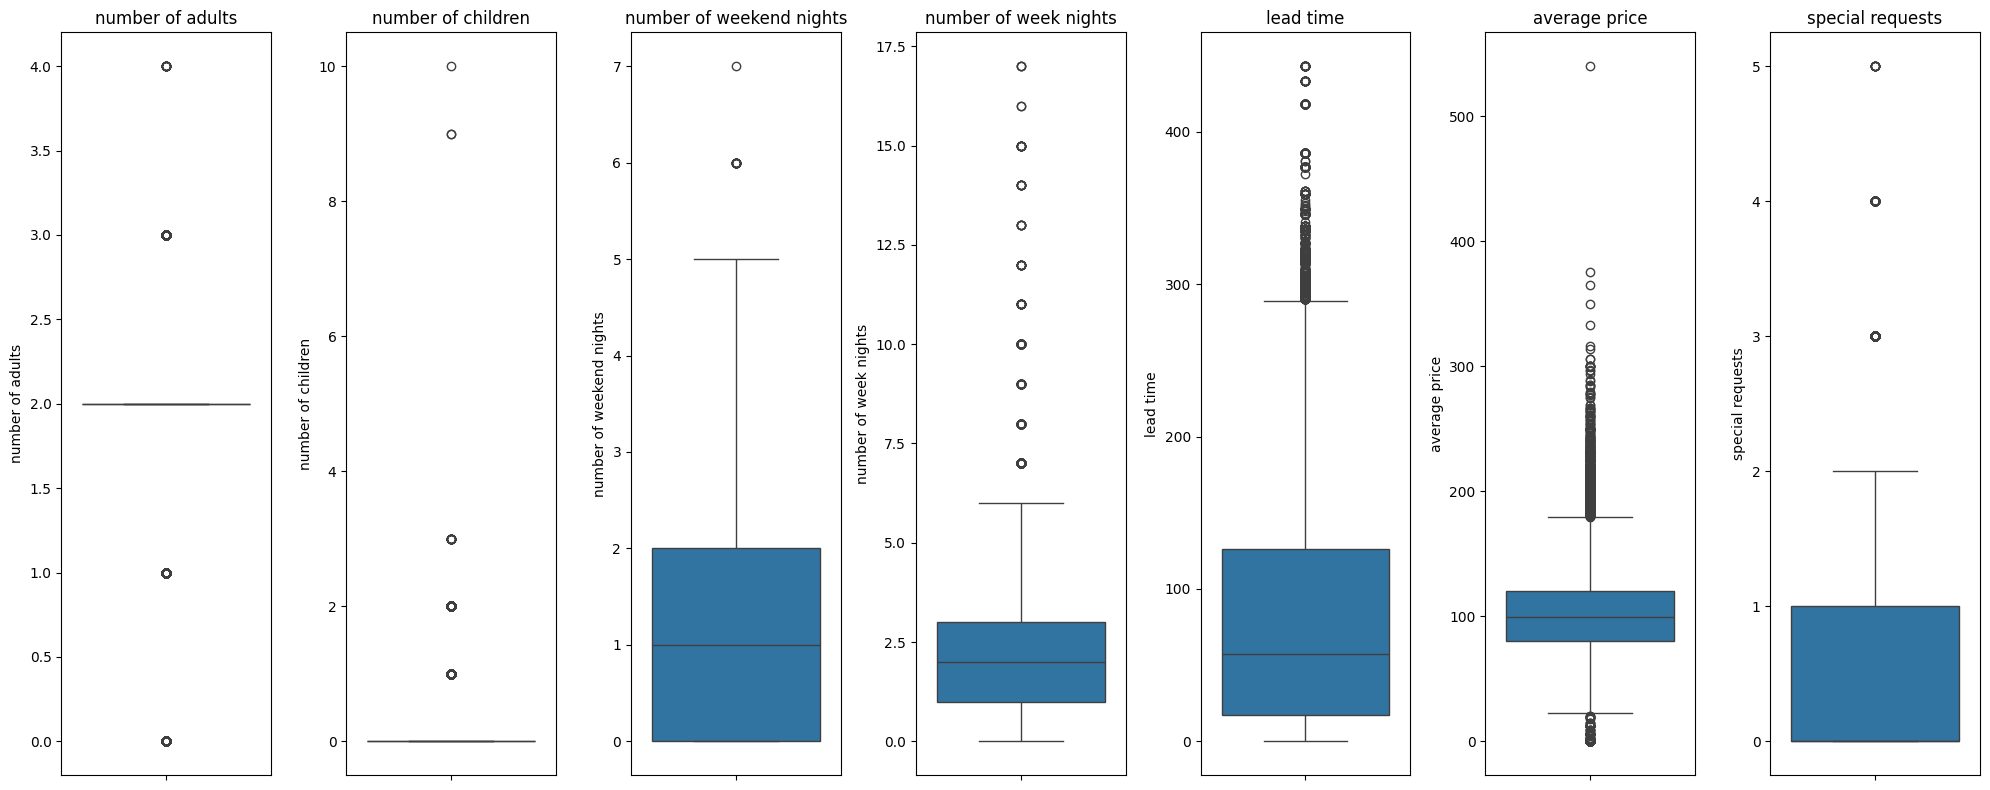

In [33]:
variables = ['number of adults','number of children','number of weekend nights','number of week nights','lead time','average price','special requests']

fig, axes = plt.subplots(1, len(variables), figsize=(20, 8))

for ax, variable in zip(axes, variables):
    sns.boxplot( y=variable, data=df_bookings, ax=ax)
    ax.set_title(variable)
    ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

Vemos variables que segun grafico de Caja Bigote podrian tener outliers. Si aplicamos IQR para todas las variables se no reduciria bastante el dataset y asimismo, no tiene sentido eliminar outliers de todas las variables ya que alguos datos son importantes.

Variables que trabajaremos OUTLIERS:
- Number of Children
- Lead Time
- Average Price
- Number of Weekend Nights
- Number of Week Nights

In [34]:
variables_outliers = ['average price', 'lead time','number of children','number of weekend nights','number of week nights'] #Añadimos variables que vamos a trabajar#

#Copia del Dataset Inicial para guardar datos#
df_bookings_limpio = df_bookings.copy()

for variable in variables_outliers:
    Q1 = df_bookings_limpio[variable].quantile(0.25)
    Q3 = df_bookings_limpio[variable].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtramos para poder remover outliers de las variables elegidas#
    df_bookings_limpio = df_bookings_limpio[(df_bookings_limpio[variable] >= limite_inferior) & (df_bookings_limpio[variable] <= limite_superior)]

print(f"DataSet Original: {df_bookings.shape}")
print(f"DataSet Limpio (outliers removed from {variables_outliers}): {df_bookings_limpio.shape}")

DataSet Original: (36285, 17)
DataSet Limpio (outliers removed from ['average price', 'lead time', 'number of children', 'number of weekend nights', 'number of week nights']): (31137, 17)


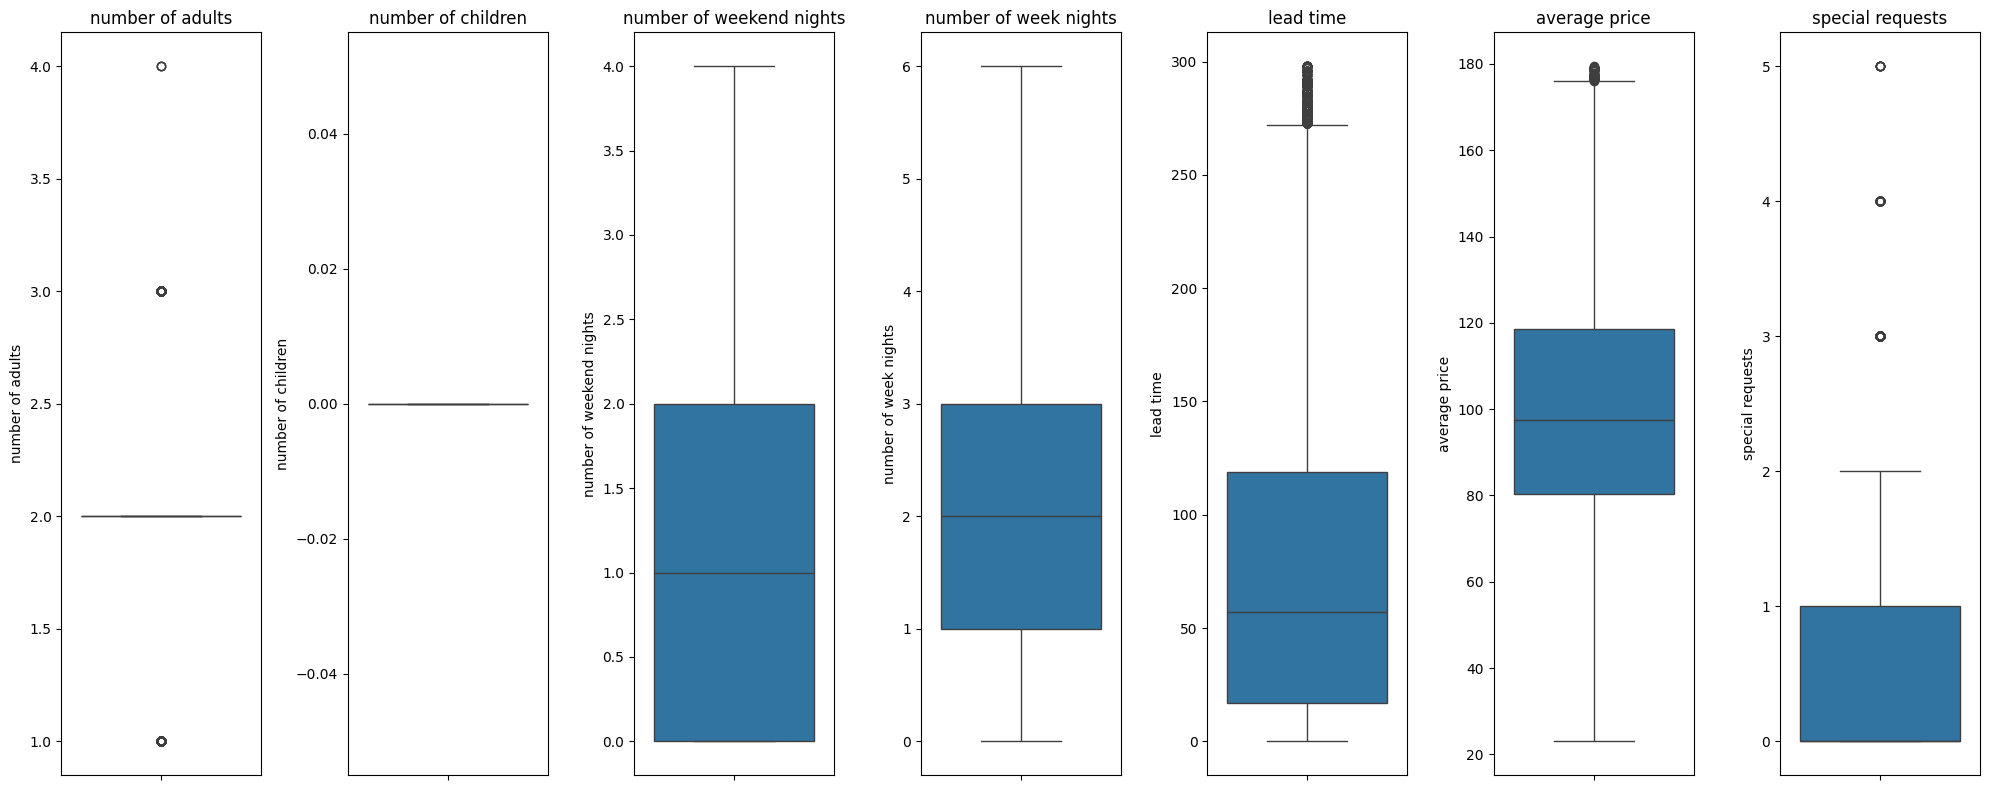

In [35]:
variables = ['number of adults','number of children','number of weekend nights','number of week nights','lead time','average price','special requests']

fig, axes = plt.subplots(1, len(variables), figsize=(20, 8))

for ax, variable in zip(axes, variables):
    sns.boxplot( y=variable, data=df_bookings_limpio, ax=ax)
    ax.set_title(variable)
    ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

**Otras transformaciones, normalización, fechas**

In [36]:
df_bookings_limpio['date of reservation'] = pd.to_datetime(df_bookings_limpio['date of reservation'], errors='coerce')

print(df_bookings_limpio['date of reservation'].dtype)
print(df_bookings_limpio.head())

datetime64[ns]
  Booking_ID  number of adults  number of children  number of weekend nights  \
1   INN00002                 1                   0                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   
7   INN00008                 3                   0                         1   
9   INN00010                 2                   0                         0   

   number of week nights  type of meal  car parking space    room type  \
1                      3  Not Selected                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   
7                      3   Meal Plan 1                  0  Room_Type 4   
9                      5   Meal Plan 1                  0  Room_Type 4   

   lead time market segment type  repeated  P-C  P-not-C  a

# **Análisis Exploratorio de datos**

**Análisis univariado**

/tmp/ipython-input-1145261164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bookings_limpio, x='number of adults', palette='viridis')


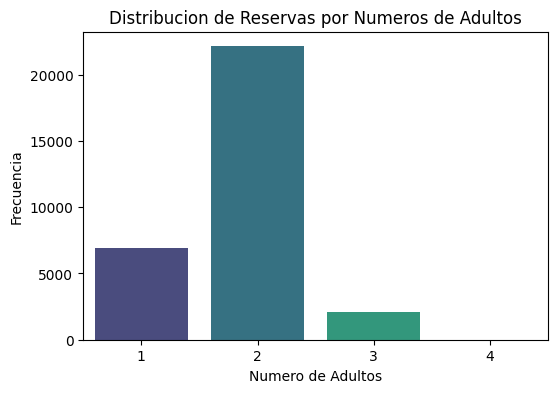

In [37]:
# Analisis de Distribucion de Reservas por Números de Adultos
plt.figure(figsize=(6, 4))
sns.countplot(data=df_bookings_limpio, x='number of adults', palette='viridis')
plt.title('Distribucion de Reservas por Numeros de Adultos')
plt.xlabel('Numero de Adultos')
plt.ylabel('Frecuencia')
plt.show()

Distribución de Reservas por Números de Adultos: Este gráfico de barras muestra la frecuencia de reservas según el número de adultos que las componen. La mayoría de las reservas son para 2 adultos, seguidas por reservas para 1 adulto. Esto indica el tamaño típico de los grupos que reservan en este establecimiento.

/tmp/ipython-input-3814655594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bookings_limpio, x='market segment type', palette='plasma')


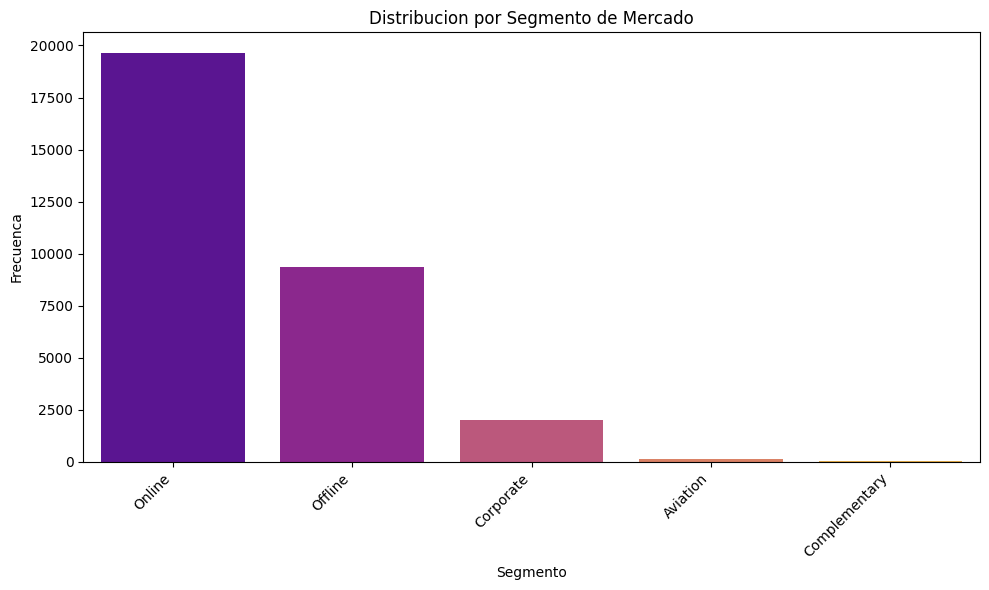

In [38]:
# Distribución por Segmento de Mercado
plt.figure(figsize=(10, 6))
sns.countplot(data=df_bookings_limpio, x='market segment type', palette='plasma')
plt.title('Distribucion por Segmento de Mercado')
plt.xlabel('Segmento')
plt.ylabel('Frecuenca')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Este gráfico de barras ilustra la cantidad de reservas originadas por cada tipo de segmento de mercado. Se confirma que el canal "Online" es el más predominante en cuanto al volumen de reservas, seguido por el canal "Offline" y las reservas "Corporate". Los segmentos "Aviation" y "Complementary" tienen una participación mucho menor.


/tmp/ipython-input-500645930.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bookings_limpio, x='room type', palette='viridis')


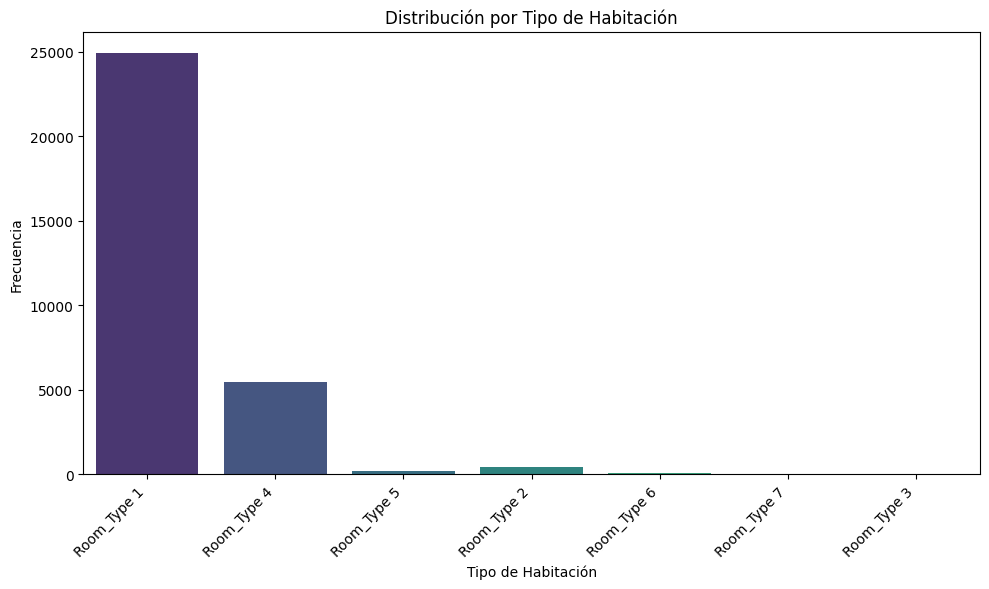

In [39]:
# Análisis de Distriubución por Tipo de Habitación
plt.figure(figsize=(10, 6))
sns.countplot(data=df_bookings_limpio, x='room type', palette='viridis')
plt.title('Distribución por Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Este gráfico de barras muestra la frecuencia de reservas para cada tipo de habitación disponible. Claramente, la "Room_Type 1" es la más solicitada con una gran diferencia respecto a las demás, seguida por la "Room_Type 4". Esto sugiere que estas son las habitaciones más populares o más numerosas en el establecimiento.

/tmp/ipython-input-2980148761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bookings_limpio, x='number of week nights', palette='viridis')


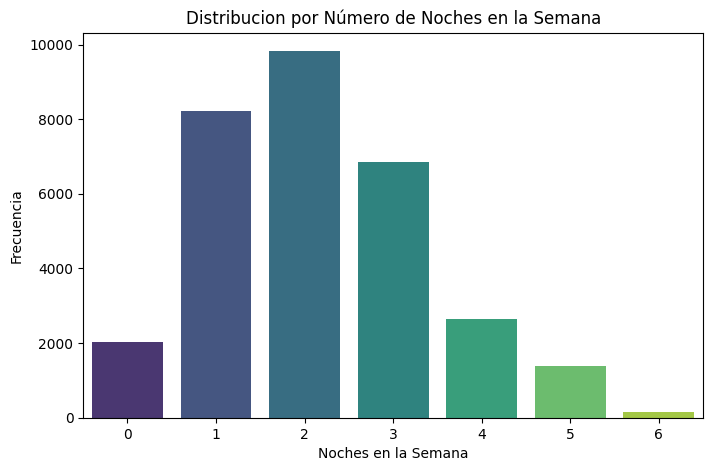

In [40]:
# Analisis de Distribucion por Numero de Noches en la Semana
plt.figure(figsize=(8, 5))
sns.countplot(data=df_bookings_limpio, x='number of week nights', palette='viridis')
plt.title('Distribucion por Número de Noches en la Semana')
plt.xlabel('Noches en la Semana')
plt.ylabel('Frecuencia')
plt.show()

 Este gráfico de barras representa la frecuencia de reservas según la cantidad de noches que la estadía incluye durante la semana (lunes a viernes). La distribución muestra que la mayoría de las reservas son para estancias cortas durante la semana, con picos en 1, 2 y 3 noches. Está sesgada hacia la derecha, indicando que estancias más largas entre semana son menos comunes.

/tmp/ipython-input-3104334320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bookings_limpio, x='number of weekend nights', palette='viridis')


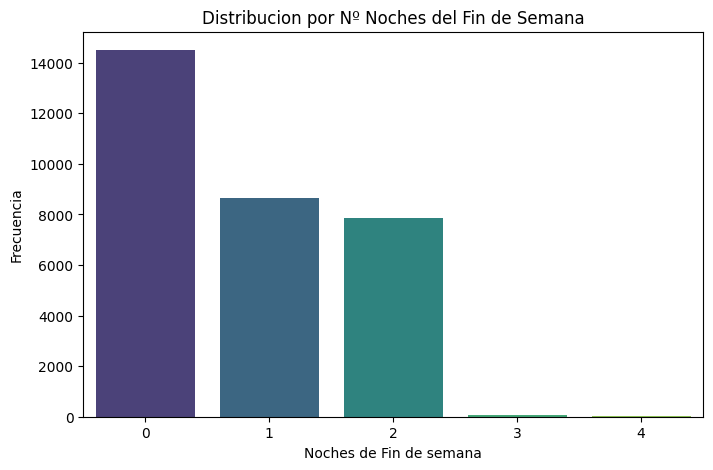

In [41]:
# Analisis de Distribucion por Numero de Noches en el fin de semana
plt.figure(figsize=(8, 5))
sns.countplot(data=df_bookings_limpio, x='number of weekend nights', palette='viridis')
plt.title('Distribucion por Nº Noches del Fin de Semana')
plt.xlabel('Noches de Fin de semana')
plt.ylabel('Frecuencia')
plt.show()

Similar al anterior, este gráfico muestra la frecuencia de reservas según la cantidad de noches que la estadía incluye durante el fin de semana (sábado y domingo). Se observa que la mayoría de las reservas no incluyen noches de fin de semana (0 noches), pero también hay una cantidad considerable de reservas que incluyen 1 o 2 noches de fin de semana. También está sesgado a la derecha.

/tmp/ipython-input-1285182931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bookings_limpio, x='booking status', palette='viridis')


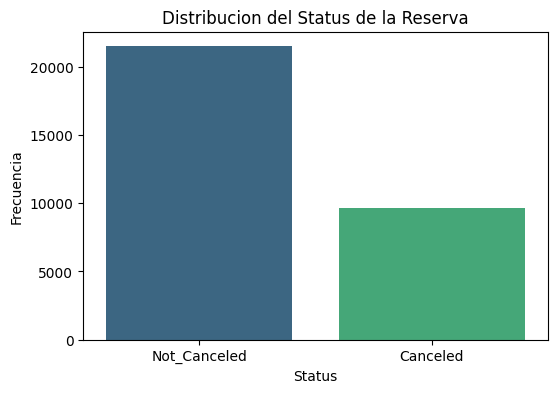

In [42]:
# Distribucion de Status de la Reserva
plt.figure(figsize=(6, 4))
sns.countplot(data=df_bookings_limpio, x='booking status', palette='viridis')
plt.title('Distribucion del Status de la Reserva')
plt.xlabel('Status')
plt.ylabel('Frecuencia')
plt.show()

Este gráfico de barras simple muestra la proporción de reservas que fueron "Not_Canceled" (no canceladas) y "Canceled" (canceladas). Hay un desbalance en la muestra, con una mayor cantidad de reservas no canceladas que canceladas. Esto es importante tener en cuenta para futuros modelos predictivos.

/tmp/ipython-input-3935288166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bookings_limpio, x='car parking space', palette='viridis')


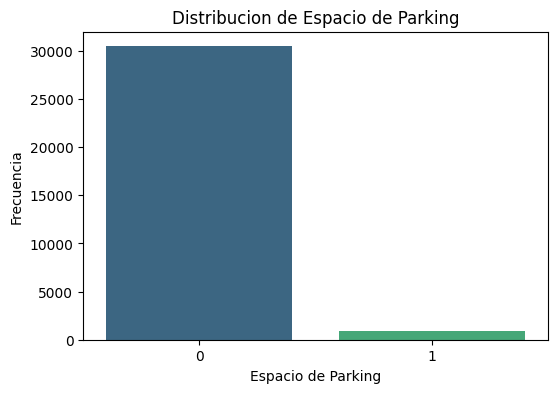

In [ ]:
# Distribucion Parking
plt.figure(figsize=(6, 4))
sns.countplot(data=df_bookings_limpio, x='car parking space', palette='viridis')
plt.title('Distribucion de Espacio de Parking')
plt.xlabel('Espacio de Parking')
plt.ylabel('Frecuencia')
plt.show()

Este gráfico de barras muestra la frecuencia de reservas que solicitaron o no espacio de estacionamiento. La gran mayoría de las reservas no solicitaron espacio de parking (0), lo que indica que el estacionamiento no es un servicio requerido por la mayoría de los huéspedes, o que no está disponible para la mayoría de las reservas.

**Análisis bivariado**

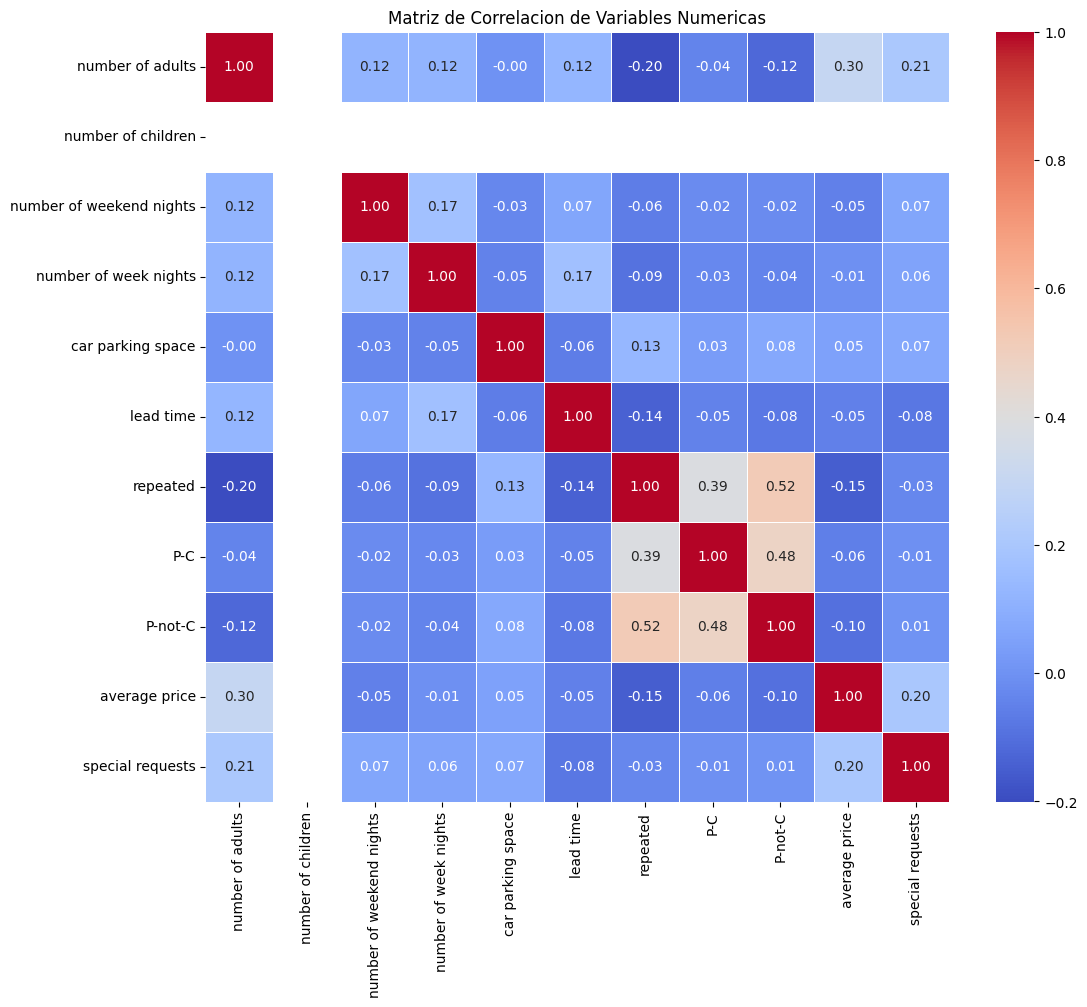

In [ ]:
# Seleccionar Variables Numericas del Data Set
df_numerico = df_bookings_limpio.select_dtypes(include=np.number)

# Calcular Matriz de Correlacion
matriz_correlacion = df_numerico.corr()

# Crear Mapa de Calor para la Matriz
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlacion de Variables Numericas')
plt.show()

Este mapa de calor visualiza la correlación entre las variables numéricas del dataset. Los valores cercanos a 1 o -1 indican una correlación fuerte (positiva o negativa respectivamente), mientras que los valores cercanos a 0 indican poca correlación.No se observan correlaciones lineales fuertes entre la mayoría de las variables numéricas. La excepción notable es una correlación positiva entre P-C y P-not-C, lo cual es esperable ya que ambas se refieren al historial de reservas del cliente.


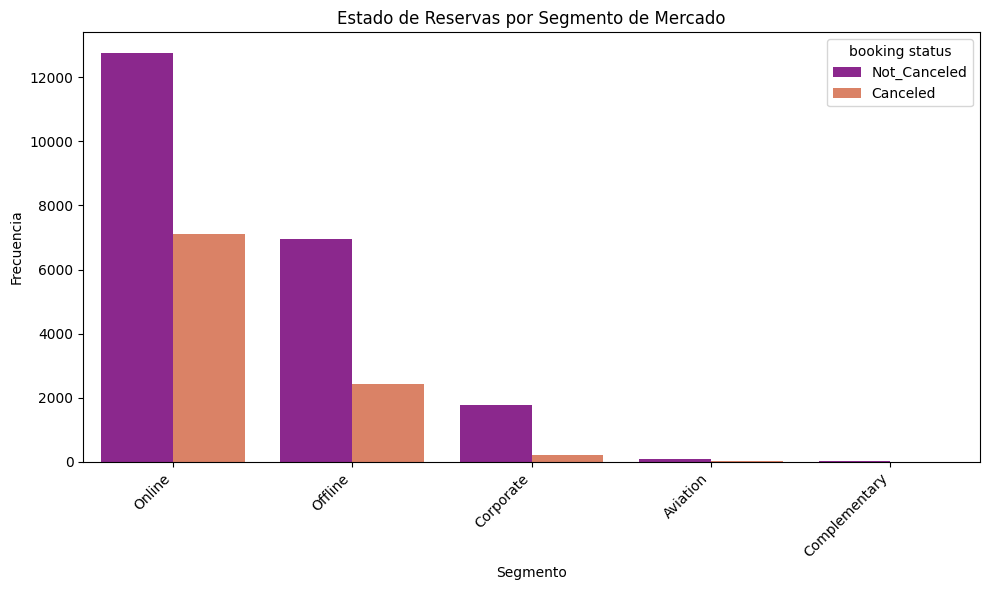

In [ ]:
# Relacion entre Segmento de Mercado y Estado de las reservas
plt.figure(figsize=(10, 6))
sns.countplot(data=df_bookings_limpio, x='market segment type', hue='booking status', palette='plasma')
plt.title('Estado de Reservas por Segmento de Mercado')
plt.xlabel('Segmento')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Este gráfico de barras agrupadas compara el número de reservas canceladas y no canceladas para cada segmento de mercado. Permite visualizar la proporción de cancelaciones dentro de cada segmento. El segmento "Online" tiene un volumen significativo de cancelaciones en comparación con otros segmentos.

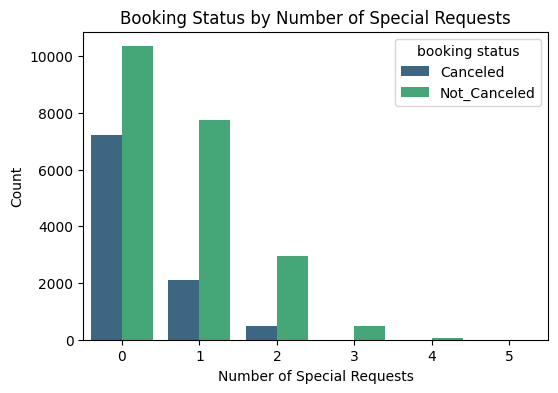

In [ ]:
# Relacion entre Requerimientos Especiales y Estado de Reserva
plt.figure(figsize=(6, 4))
sns.countplot(data=df_bookings_limpio, x='special requests', hue='booking status', palette='viridis')
plt.title('Status de Reserva por Numero de Requerimiento Especiales')
plt.xlabel('Requerimientos Especiales')
plt.ylabel('Frecuencia')
plt.show()

 Este gráfico de barras agrupadas muestra cómo el número de solicitudes especiales se relaciona con el estado de la reserva. Observaste correctamente que las reservas con un mayor número de solicitudes especiales tienden a tener una menor tasa de cancelación. Esto sugiere que hacer solicitudes especiales puede ser un indicador de un cliente más comprometido con la reserva.

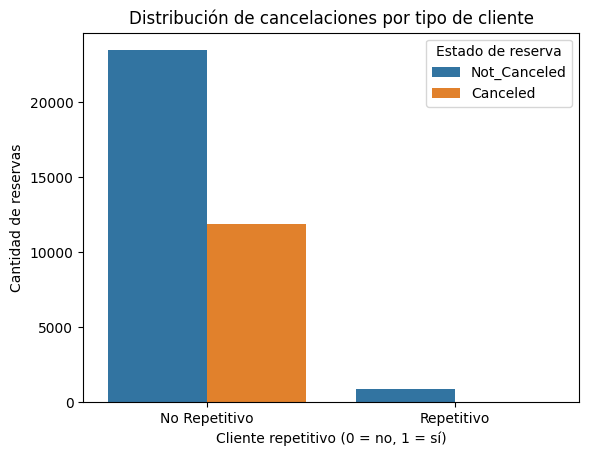

In [ ]:
sns.countplot(data=df_bookings, x='repeated', hue='booking status')
plt.title('Distribución de cancelaciones por tipo de cliente')
plt.xlabel('Cliente repetitivo (0 = no, 1 = sí)')
plt.ylabel('Cantidad de reservas')
plt.xticks([0,1], ['No Repetitivo', 'Repetitivo'])
plt.legend(title='Estado de reserva')
plt.show()

Este gráfico de barras agrupadas compara el número de reservas canceladas y no canceladas para clientes repetitivos y no repetitivos. Los clientes repetitivos tienen una tasa de cancelación muy baja en comparación con los clientes nuevos, aunque el número total de clientes repetitivos en el dataset es menor.

/tmp/ipython-input-2168213518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bookings_limpio, x='market segment type', y='average price', palette='plasma')


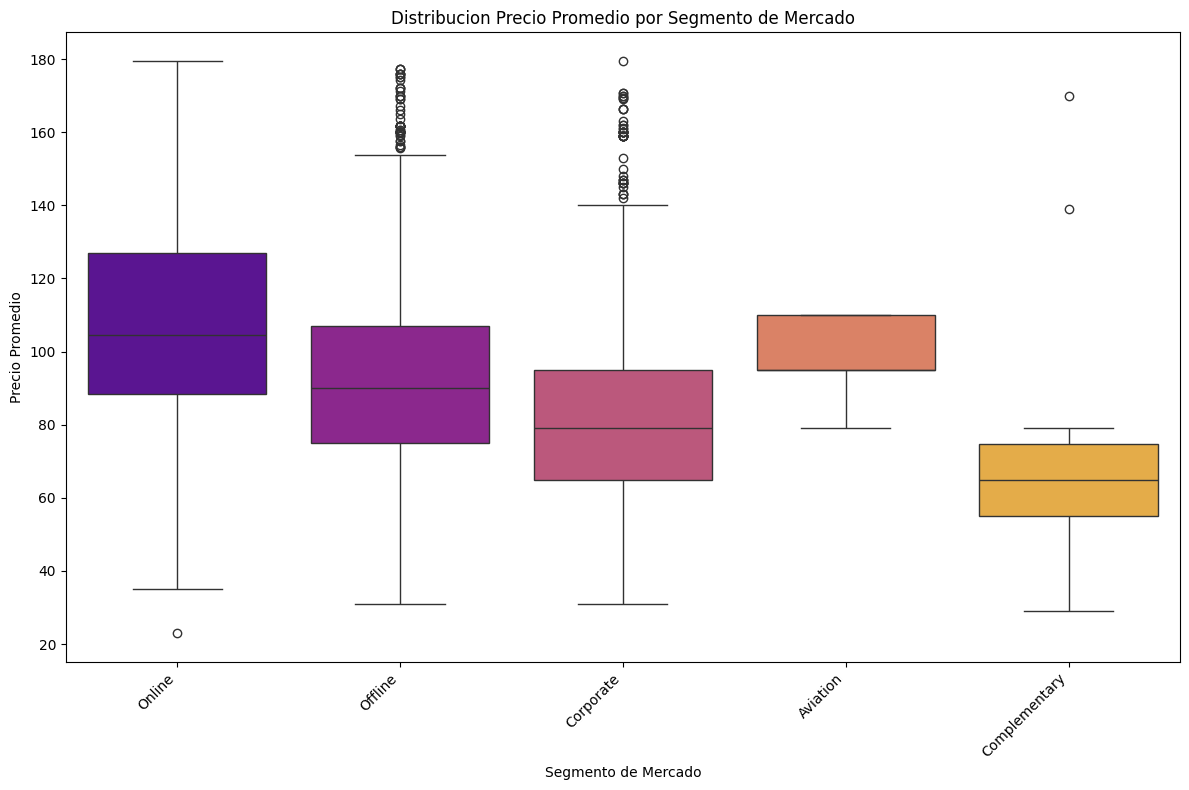

In [ ]:
# Relacion entre Precio promedio por Segmento de Mercado
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_bookings_limpio, x='market segment type', y='average price', palette='plasma')
plt.title('Distribucion Precio Promedio por Segmento de Mercado')
plt.xlabel('Segmento de Mercado')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Este boxplot agrupado muestra la distribución del precio promedio por noche para cada segmento de mercado, separado por el estado de la reserva (cancelada o no cancelada). Se puede observar una leve tendencia en los segmentos con más reservas (Online y Offline) a que las reservas canceladas tengan un precio promedio ligeramente superior a las no canceladas.

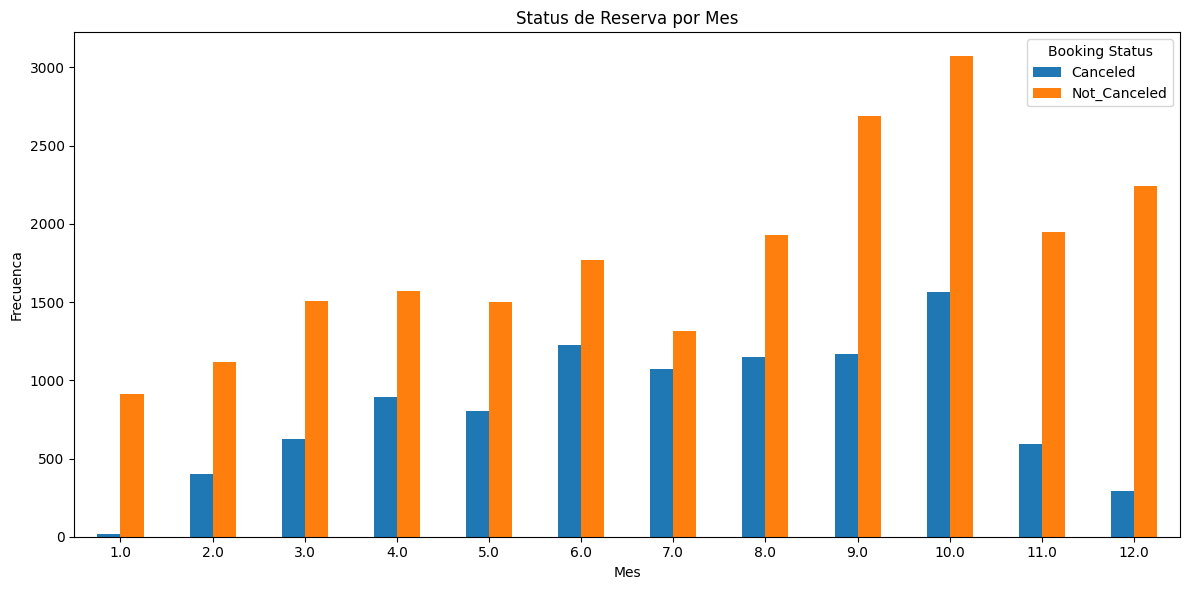

In [ ]:
#Extraer Mes del Tiempo
if 'reservation_month' not in df_bookings_limpio.columns:
    df_bookings_limpio['reservation_month'] = df_bookings_limpio['date of reservation'].dt.month

monthly_booking_status = df_bookings_limpio.groupby(['reservation_month', 'booking status']).size().unstack(fill_value=0)

ax = monthly_booking_status.plot(kind='bar', figsize=(12, 6))
plt.title('Status de Reserva por Mes')
plt.xlabel('Mes')
plt.ylabel('Frecuenca')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

Octubre es el mes con mas cancelaciones pero a su vez con mas reservas. El mes donde proporcionalmente hay mas reservas canceladas son Julio y Junio. Los meses que menos Enero, Noviembre y Diciembre.

Las 10 combinaciones con más cancelaciones son:


,combination,count
0,Room_Type 1 - Online - Meal Plan 1 - Repeated:...,2378
1,Room_Type 1 - Online - Not Selected - Repeated...,1475
2,Room_Type 1 - Offline - Meal Plan 1 - Repeated...,1111
3,Room_Type 4 - Online - Meal Plan 1 - Repeated:...,1050
4,Room_Type 1 - Online - Meal Plan 1 - Repeated:...,626
5,Room_Type 4 - Online - Meal Plan 1 - Repeated:...,618
6,Room_Type 1 - Offline - Meal Plan 1 - Repeated...,597
7,Room_Type 1 - Offline - Meal Plan 2 - Repeated...,589
8,Room_Type 1 - Online - Meal Plan 2 - Repeated:...,264
9,Room_Type 1 - Online - Not Selected - Repeated...,125


/tmp/ipython-input-3867616669.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='combination', y='count', data=top_10_combinations, palette='viridis')


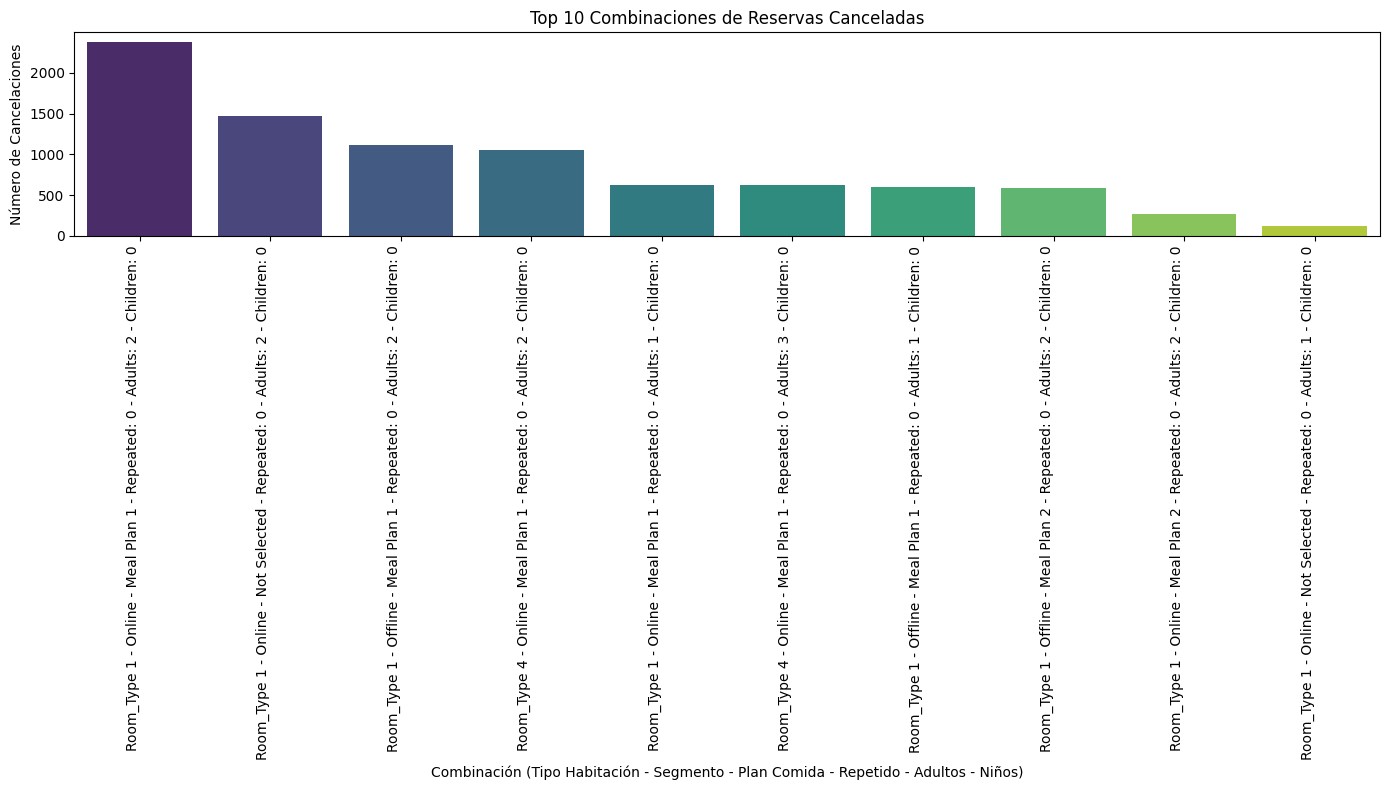

Este gráfico de barras muestra las 10 combinaciones de características de reserva que resultaron en la mayor cantidad de cancelaciones. Cada barra representa una combinación específica, detallando el tipo de habitación, el segmento de mercado, el plan de comida, si el cliente es repetitivo, el número de adultos y el número de niños.

Las combinaciones más frecuentes entre las reservas canceladas a menudo involucran la "Room_Type 1" y el segmento de mercado "Online", lo cual concuerda con hallazgos previos sobre estos factores.

El plan de comida "Meal Plan 1" también aparece prominentemente en las combinaciones con más cancelaciones.

En la mayoría de las combinaciones principales, el cliente no es repetitivo (Repeated: 0), lo que refuerza la idea de que los clientes nuevos tienen una mayor propensión a cancelar.

**Análisis multivariado**

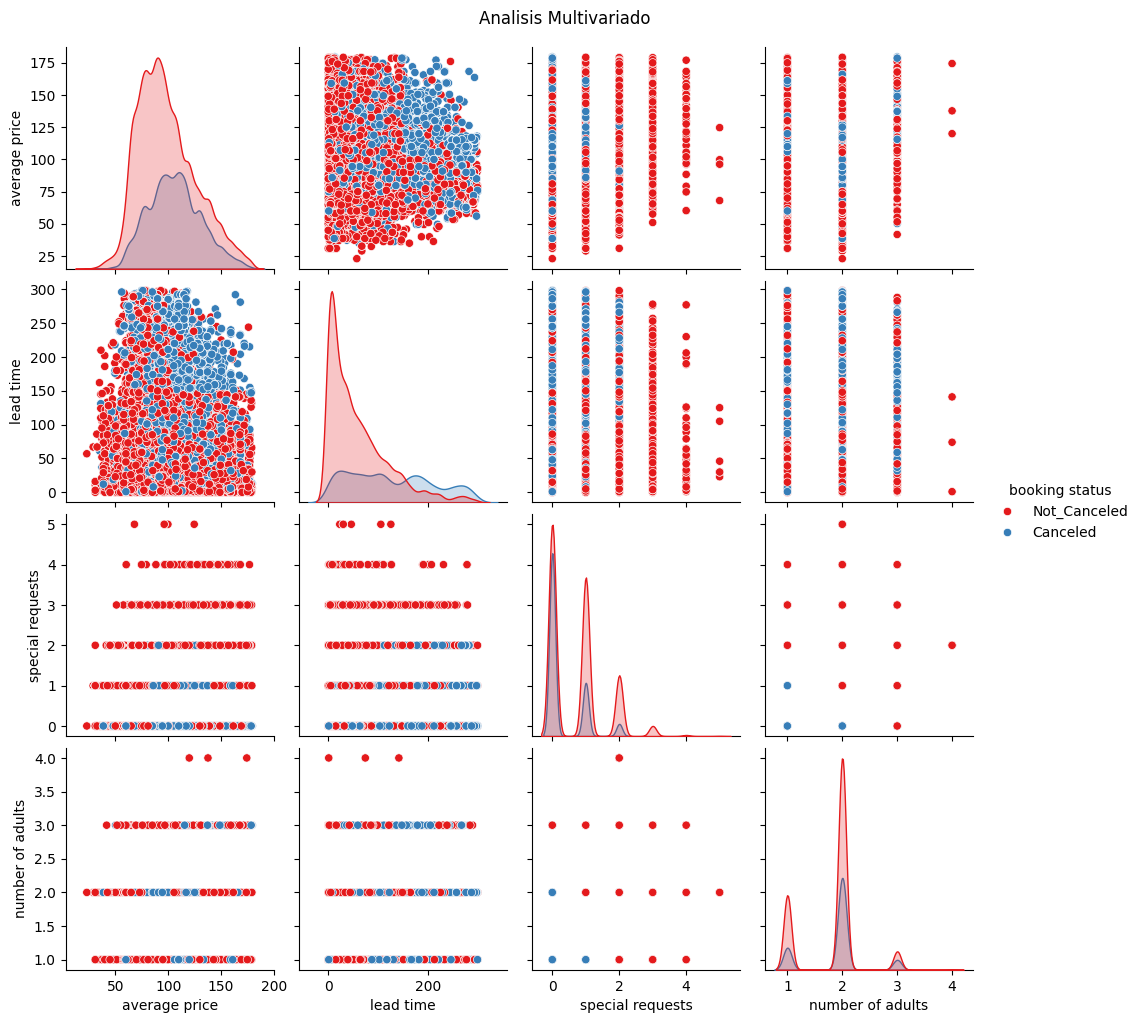

In [ ]:
# Pairplot of some key variables
selected_columns = ['average price', 'lead time', 'special requests', 'number of adults', 'booking status'] # Added 'booking status' for hue
sns.pairplot(df_bookings_limpio[selected_columns], hue='booking status', palette='Set1')
plt.suptitle('Analisis Multivariado', y=1.02)
plt.show()

Este conjunto de gráficos de dispersión y histogramas (Pairplot) muestra las relaciones bivariadas entre un conjunto seleccionado de variables numéricas, utilizando el estado de la reserva como color (hue). Permite visualizar patrones y separabilidad entre los dos estados de reserva en función de estas variables. Por ejemplo, en el gráfico de dispersión entre average price y lead time, puedes ver la distribución de los puntos de datos para reservas canceladas y no canceladas. Los histogramas en la diagonal muestran la distribución univariada de cada variable para cada estado de reserva.

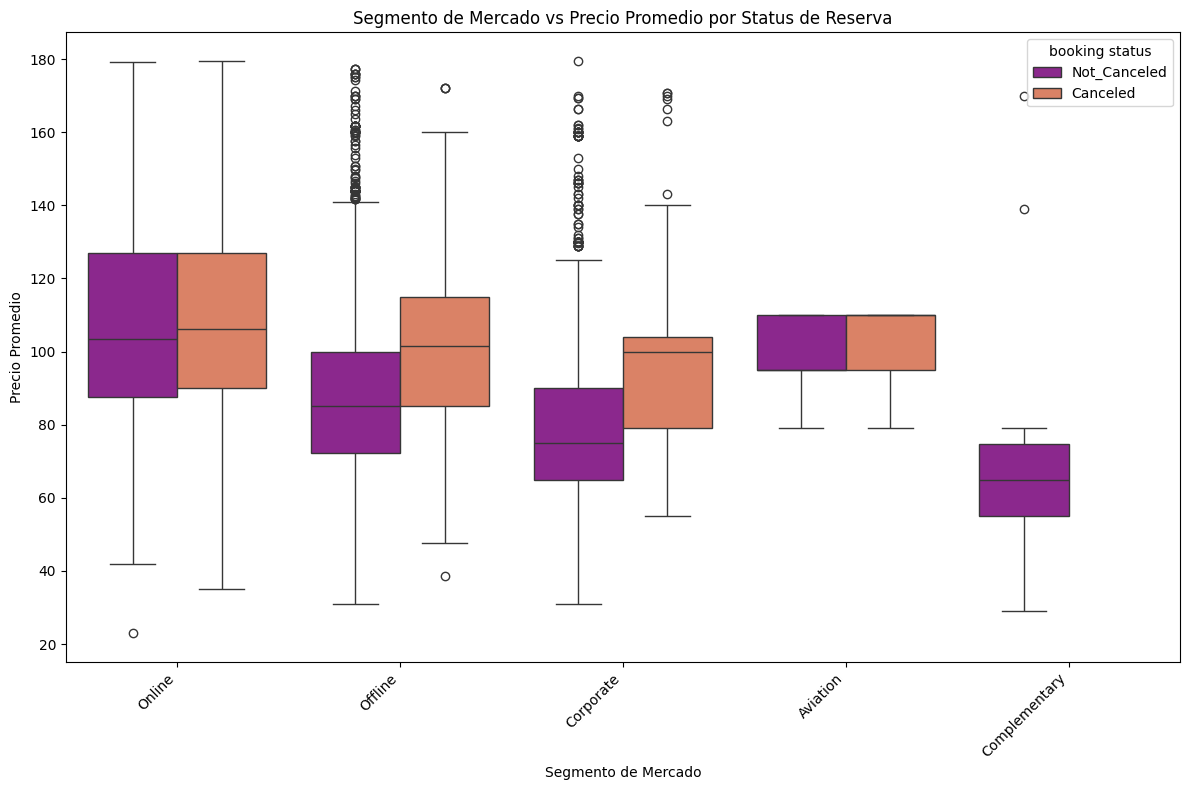

In [ ]:
# Relationship between Room Type, Average Price, and Booking Status
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_bookings_limpio, x='market segment type', y='average price', hue='booking status', palette='plasma')
plt.title('Segmento de Mercado vs Precio Promedio por Status de Reserva')
plt.xlabel('Segmento de Mercado')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Se ve una leve tendencia en los segmentos mas importantes que la cancelaciones de reservas tienen una precio promedio mas alto que las no canceladas.

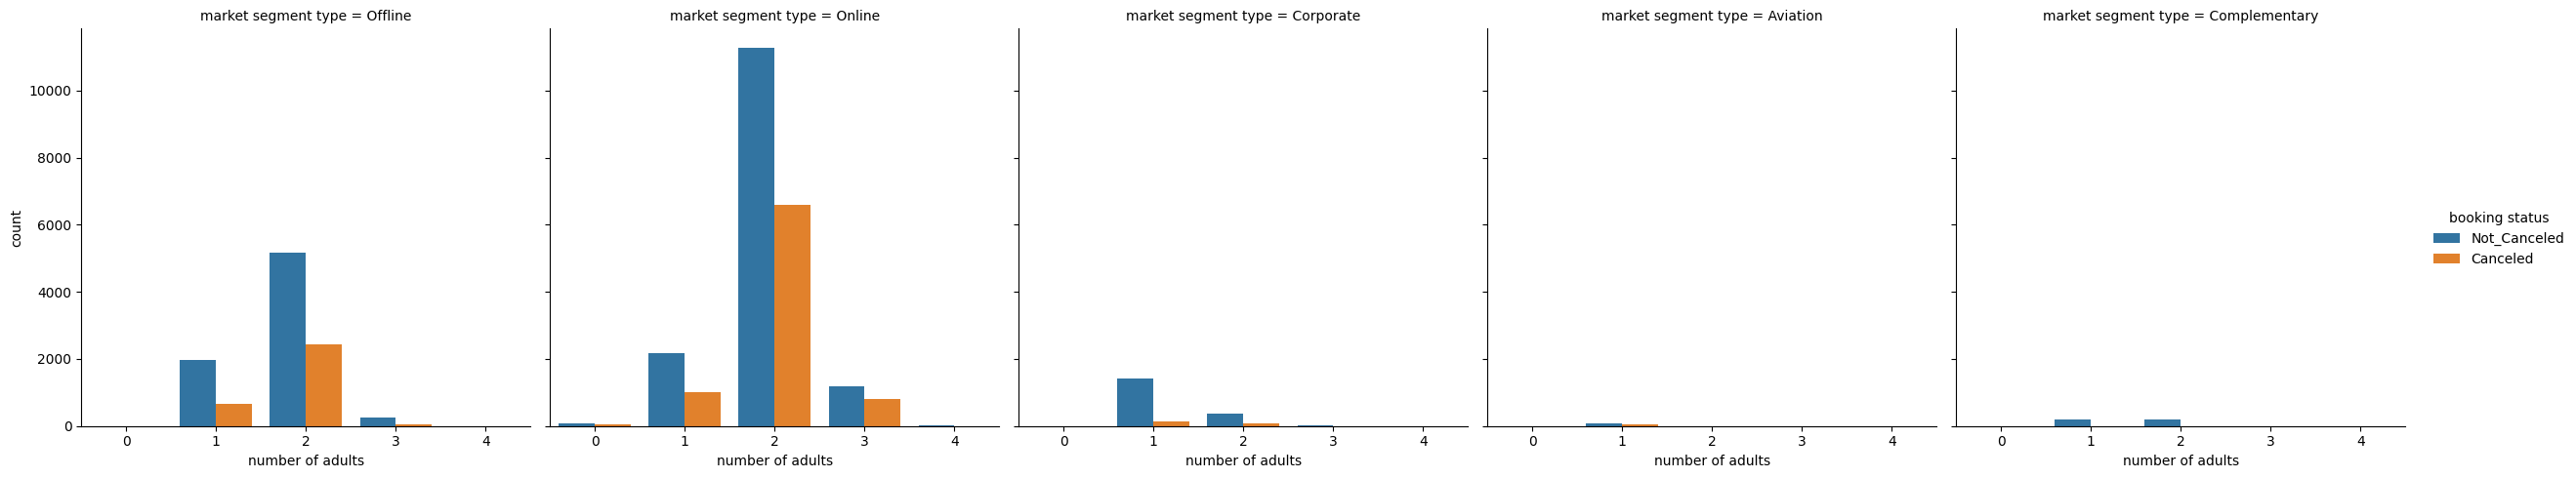

In [ ]:
sns.catplot(data=df_bookings, x="number of adults", hue="booking status", col="market segment type", kind="count")


Este conjunto de gráficos de barras (Catplot) desglosa la cantidad de reservas canceladas y no canceladas por el número de adultos, para cada segmento de mercado. Permite comparar los patrones de cancelación por tamaño de grupo y canal de reserva. Observaste que los segmentos "Online" y "Offline" tienen patrones de cancelación similares en cuanto al número de adultos, mientras que el segmento "Corporate" tiene una tasa de cancelación más baja, especialmente para grupos más grandes.

**Conclusiones del EDA**

*Conclusiones del Análisis Exploratorio de Datos (EDA)*

*Alta proporción de cancelaciones generales:*
Aproximadamente el 33% de las reservas fueron canceladas, lo que representa un volumen considerable desde el punto de vista operativo y económico.

*El lead time es un factor crítico:*
Se observó que las reservas realizadas con mayor anticipación (más días de lead time) presentan una mayor probabilidad de cancelación. Esto sugiere que las reservas planificadas con mucho tiempo suelen ser más susceptibles a cambios de intención, imprevistos o falta de compromiso.

*Clientes repetitivos cancelan menos*
El análisis comparativo reveló que los clientes que ya habían reservado en el pasado (repeated = 1) tienen una tasa de cancelación sensiblemente menor que los nuevos. Esto refuerza la idea de que la fidelización y el conocimiento previo del servicio reducen el comportamiento de cancelación.

*El número de solicitudes especiales está inversamente relacionado con las cancelaciones*
Aquellos clientes que realizaron solicitudes especiales (special requests) cancelan en menor proporción. Esto puede deberse a un mayor nivel de involucramiento o expectativas más específicas, lo que reduce la probabilidad de abandono.

*El canal de reserva influye significativamente*
Las reservas realizadas a través de canales online presentan una tasa de cancelación mayor que las realizadas offline o mediante canales corporativos. Esto sugiere que los canales digitales, aunque más masivos, pueden requerir políticas más estrictas o filtros adicionales para mejorar la calidad de las reservas.

*El precio promedio no mostró una correlación fuerte directa *
A pesar de la intuición de que los precios más bajos podrían asociarse con más cancelaciones, el análisis no encontró una relación lineal clara entre el average price y la tasa de cancelación. Sin embargo, este punto podría explorarse mejor en combinación con otras variables mediante un modelo predictivo.

*Verano tiene los meses con mayor cantidad de cancelaciones*
Suelen concentrarse en junio, julio y agosto, lo cual coincide con el verano europeo. Es un período de alta demanda, y también de muchas reservas anticipadas que luego se cancelan por cambios de planes.

